In [1]:
"""
Лабораторная работа №3: Марковский процесс принятия решений (MDP)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import clear_output
import time

In [2]:
# Часть 1: Определение MDP и вспомогательные функции

# Определение переходов и вознаграждений для простого MDP
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}

rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}


class MDP:
    """
    Класс, реализующий Марковский процесс принятия решений.
    Аналогичен Gym среде.
    """
    def __init__(self, transition_probs, rewards, initial_state=None):
        self.transition_probs = transition_probs
        self.rewards = rewards
        self.initial_state = initial_state
        self.current_state = initial_state
        self._states = sorted(list(transition_probs.keys()))

    def reset(self):
        """Сброс среды в начальное состояние"""
        self.current_state = self.initial_state
        return self.current_state

    def step(self, action):
        """Выполнение действия и получение следующего состояния, награды и флага завершения"""
        if self.current_state is None:
            raise ValueError("Среда не инициализирована. Вызовите reset() сначала.")

        # Получение вероятностей переходов для текущего состояния и действия
        next_state_probs = self.transition_probs[self.current_state][action]

        # Выбор следующего состояния на основе вероятностей
        next_states = list(next_state_probs.keys())
        probs = list(next_state_probs.values())
        next_state = np.random.choice(next_states, p=probs)

        # Получение награды
        reward = 0.0
        if self.current_state in self.rewards:
            if action in self.rewards[self.current_state]:
                if next_state in self.rewards[self.current_state][action]:
                    reward = self.rewards[self.current_state][action][next_state]

        # Проверка, является ли состояние терминальным
        done = False

        self.current_state = next_state
        return next_state, reward, done, {}

    def get_all_states(self):
        """Возвращает все возможные состояния"""
        return tuple(self._states)

    def get_possible_actions(self, state):
        """Возвращает все возможные действия для заданного состояния"""
        return tuple(self.transition_probs[state].keys())

    def get_next_states(self, state, action):
        """Возвращает словарь следующих состояний с их вероятностями"""
        return self.transition_probs[state][action]

    def get_transition_prob(self, state, action, next_state):
        """Возвращает вероятность перехода из state в next_state при выполнении action"""
        return self.transition_probs[state][action].get(next_state, 0)

    def get_reward(self, state, action, next_state):
        """Возвращает награду за переход из state в next_state при выполнении action"""
        if state in self.rewards:
            if action in self.rewards[state]:
                if next_state in self.rewards[state][action]:
                    return self.rewards[state][action][next_state]
        return 0.0

    def is_terminal(self, state):
        """Проверяет, является ли состояние терминальным"""
        return False  # В данном MDP нет терминальных состояний

In [3]:
# Создание экземпляра MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

print('initial state =', mdp.reset())
next_state, reward, done, info = mdp.step('a1')
print('next_state = %s, reward = %s, done = %s' % (next_state, reward, done))

print("\nmdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ", mdp.get_transition_prob('s1', 'a0', 's0'))

initial state = s0
next_state = s2, reward = 0.0, done = False

mdp.get_all_states = ('s0', 's1', 's2')
mdp.get_possible_actions('s1') =  ('a0', 'a1')
mdp.get_next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
mdp.get_reward('s1', 'a0', 's0') =  5
mdp.get_transition_prob('s1', 'a0', 's0') =  0.7


In [4]:
# Часть 2: Итерации по значениям (Value Iteration)

def get_action_value(mdp, state_values, state, action, gamma):
    """
    Вычисляет Q(s,a) по формуле:
    Q(s,a) = sum_{s'} P(s'|s,a) * [r(s,a,s') + gamma * V(s')]
    """
    next_states = mdp.get_next_states(state, action)
    q_value = 0.0

    for next_state, prob in next_states.items():
        reward = mdp.get_reward(state, action, next_state)
        q_value += prob * (reward + gamma * state_values[next_state])

    return q_value


def get_new_state_value(mdp, state_values, state, gamma):
    """
    Вычисление следующего V(s) по формуле:
    V(s) = max_a Q(s,a)
    """
    if mdp.is_terminal(state):
        return 0

    actions = mdp.get_possible_actions(state)
    if not actions:
        return 0

    max_q = -float('inf')
    for action in actions:
        q_value = get_action_value(mdp, state_values, state, action, gamma)
        if q_value > max_q:
            max_q = q_value

    return max_q

In [6]:
# Тестирование функций
test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
print("\nТестирование get_action_value:")
print("Q(s2,a1) =", get_action_value(mdp, test_Vs, 's2', 'a1', 0.9))
print("Q(s1,a0) =", get_action_value(mdp, test_Vs, 's1', 'a0', 0.9))

# Выполнение Value Iteration
gamma = 0.9
num_iter = 100
min_difference = 0.001

# Инициализация V(s)
state_values = {s: 0 for s in mdp.get_all_states()}

print("Запуск Value Iteration")


Тестирование get_action_value:
Q(s2,a1) = 0.6900000000000002
Q(s1,a0) = 3.9499999999999997
Запуск Value Iteration


In [7]:
value_history = {s: [] for s in mdp.get_all_states()}

for i in range(num_iter):
    # Вычисление новых значений состояния
    new_state_values = {}
    for s in mdp.get_all_states():
        new_state_values[s] = get_new_state_value(mdp, state_values, s, gamma)

    # Сохраняем историю для графика
    for s in mdp.get_all_states():
        value_history[s].append(new_state_values[s])

    # Вычисление отклонений
    diff = max(abs(new_state_values[s] - state_values[s]) for s in mdp.get_all_states())

    # Вывод прогресса
    print("iter %4i | diff: %6.5f | " % (i, diff), end="")
    print(" ".join("V(%s) = %.3f" % (s, state_values[s]) for s in mdp.get_all_states()))

    state_values = new_state_values

    if diff < min_difference:
        print("Terminated")
        break

print("\nFinal state values:", state_values)

iter    0 | diff: 3.50000 | V(s0) = 0.000 V(s1) = 0.000 V(s2) = 0.000
iter    1 | diff: 0.64500 | V(s0) = 0.000 V(s1) = 3.500 V(s2) = 0.000
iter    2 | diff: 0.58050 | V(s0) = 0.000 V(s1) = 3.815 V(s2) = 0.645
iter    3 | diff: 0.43582 | V(s0) = 0.581 V(s1) = 3.959 V(s2) = 0.962
iter    4 | diff: 0.30634 | V(s0) = 0.866 V(s1) = 4.395 V(s2) = 1.272
iter    5 | diff: 0.27571 | V(s0) = 1.145 V(s1) = 4.670 V(s2) = 1.579
iter    6 | diff: 0.24347 | V(s0) = 1.421 V(s1) = 4.926 V(s2) = 1.838
iter    7 | diff: 0.21419 | V(s0) = 1.655 V(s1) = 5.169 V(s2) = 2.075
iter    8 | diff: 0.19277 | V(s0) = 1.868 V(s1) = 5.381 V(s2) = 2.290
iter    9 | diff: 0.17327 | V(s0) = 2.061 V(s1) = 5.573 V(s2) = 2.481
iter   10 | diff: 0.15569 | V(s0) = 2.233 V(s1) = 5.746 V(s2) = 2.654
iter   11 | diff: 0.14012 | V(s0) = 2.389 V(s1) = 5.902 V(s2) = 2.810
iter   12 | diff: 0.12610 | V(s0) = 2.529 V(s1) = 6.042 V(s2) = 2.950
iter   13 | diff: 0.11348 | V(s0) = 2.655 V(s1) = 6.168 V(s2) = 3.076
iter   14 | diff: 0.

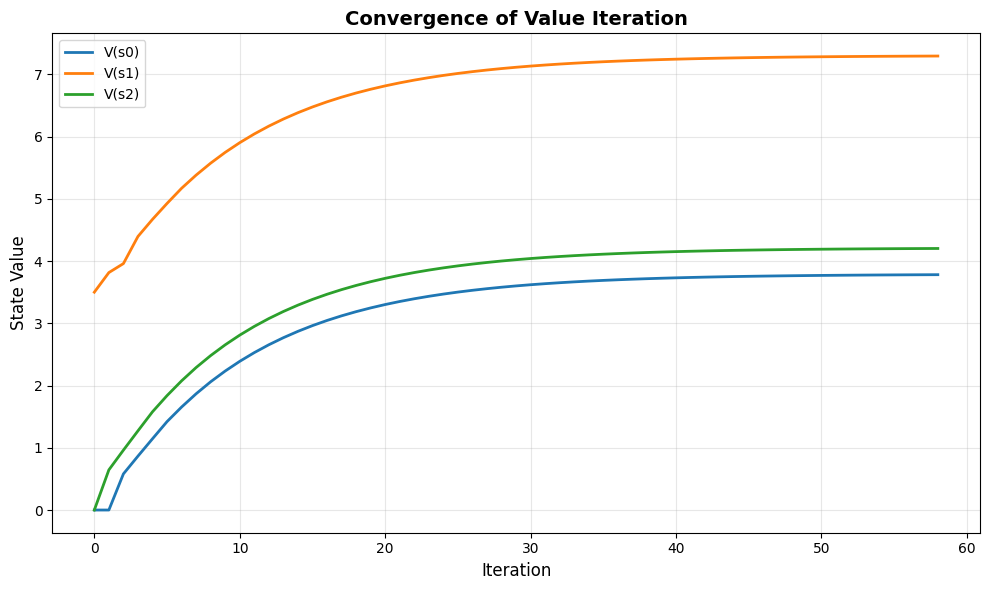


Проверка пройдена!


In [8]:
# График сходимости Value Iteration
plt.figure(figsize=(10, 6))
for s in mdp.get_all_states():
    plt.plot(value_history[s], label=f'V({s})', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('State Value', fontsize=12)
plt.title('Convergence of Value Iteration', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Проверка результатов
assert abs(state_values['s0'] - 3.781) < 0.01
assert abs(state_values['s1'] - 7.294) < 0.01
assert abs(state_values['s2'] - 4.202) < 0.01
print("\nПроверка пройдена!")

In [9]:
def get_optimal_action(mdp, state_values, state, gamma=0.9):
    """
    Находит оптимальное действие используя формулу:
    pi*(s) = argmax_a Q(s,a)
    """
    if mdp.is_terminal(state):
        return None

    actions = mdp.get_possible_actions(state)
    if not actions:
        return None

    best_action = None
    best_q = -float('inf')

    for action in actions:
        q_value = get_action_value(mdp, state_values, state, action, gamma)
        if q_value > best_q:
            best_q = q_value
            best_action = action

    return best_action


# Проверка оптимальных действий
print("\nОптимальные действия:")
print("s0 ->", get_optimal_action(mdp, state_values, 's0', gamma))
print("s1 ->", get_optimal_action(mdp, state_values, 's1', gamma))
print("s2 ->", get_optimal_action(mdp, state_values, 's2', gamma))

assert get_optimal_action(mdp, state_values, 's0', gamma) == 'a1'
assert get_optimal_action(mdp, state_values, 's1', gamma) == 'a0'
assert get_optimal_action(mdp, state_values, 's2', gamma) == 'a1'
print("\nПроверка оптимальных действий пройдена!")



Оптимальные действия:
s0 -> a1
s1 -> a0
s2 -> a1

Проверка оптимальных действий пройдена!


In [10]:
# Измерение среднего вознаграждения агента
s = mdp.reset()
rewards = []
for _ in range(10000):
    action = get_optimal_action(mdp, state_values, s, gamma)
    s, r, done, _ = mdp.step(action)
    rewards.append(r)

print(f"\nСреднее вознаграждение: {np.mean(rewards):.4f}")
assert 0.40 < np.mean(rewards) < 0.55
print("Проверка среднего вознаграждения пройдена!")


Среднее вознаграждение: 0.4694
Проверка среднего вознаграждения пройдена!


In [12]:
# Часть 3: Среда Frozen Lake

class FrozenLakeEnv:
    """
    Реализация среды Frozen Lake для обучения с подкреплением.
    """
    def __init__(self, slip_chance=0.0, map_name='4x4'):
        self.slip_chance = slip_chance

        # Стандартная карта 4x4
        if map_name == '4x4':
            self.desc = np.array([
                list('SFFF'),
                list('FHFH'),
                list('FFFH'),
                list('HFFG')
            ])
        else:
            # Карта 8x8
            self.desc = np.array([
                list('SFFFFFFF'),
                list('FFFFFFFF'),
                list('FFFHFFFF'),
                list('FFFFFHFF'),
                list('FFFHFFFF'),
                list('FHHFFFHF'),
                list('FHFFHFHF'),
                list('FFFHFFFG')
            ])

        self.n_rows, self.n_cols = self.desc.shape
        self.n_states = self.n_rows * self.n_cols
        self.n_actions = 4  # 0: вверх, 1: вниз, 2: влево, 3: вправо

        self.current_state = None
        self._initial_state = 0  # S в верхнем левом углу

    def _state_to_coords(self, state):
        """Преобразует индекс состояния в координаты (row, col)"""
        return state // self.n_cols, state % self.n_cols

    def _coords_to_state(self, row, col):
        """Преобразует координаты в индекс состояния"""
        return row * self.n_cols + col

    def _get_legal_actions(self, state):
        """Возвращает список возможных действий из состояния"""
        return list(range(self.n_actions))

    def reset(self):
        """Сброс среды в начальное состояние"""
        self.current_state = self._initial_state
        return self.current_state

    def step(self, action):
        """Выполнение действия"""
        row, col = self._state_to_coords(self.current_state)

        # Определение фактического действия с учетом вероятности скольжения
        if np.random.random() < self.slip_chance:
            actual_action = np.random.randint(self.n_actions)
        else:
            actual_action = action

        # Вычисление новых координат
        if actual_action == 0:  # вверх
            row = max(0, row - 1)
        elif actual_action == 1:  # вниз
            row = min(self.n_rows - 1, row + 1)
        elif actual_action == 2:  # влево
            col = max(0, col - 1)
        elif actual_action == 3:  # вправо
            col = min(self.n_cols - 1, col + 1)

        new_state = self._coords_to_state(row, col)

        # Определение награды и флага завершения
        cell = self.desc[row, col]

        if cell == 'G':  # Цель
            reward = 1.0
            done = True
        elif cell == 'H':  # Дыра
            reward = 0.0
            done = True
        else:  # Обычное поле
            reward = 0.0
            done = False

        self.current_state = new_state
        return new_state, reward, done, {}

    def render(self):
        """Визуализация текущего состояния"""
        for i in range(self.n_rows):
            row_str = ''
            for j in range(self.n_cols):
                if self._coords_to_state(i, j) == self.current_state:
                    row_str += '🤖 '
                else:
                    row_str += self.desc[i, j] + ' '
            print(row_str)
        print()

    def get_all_states(self):
        """Возвращает все возможные состояния"""
        return list(range(self.n_states))

    def get_possible_actions(self, state):
        """Возвращает все возможные действия для заданного состояния"""
        return self._get_legal_actions(state)

    def get_next_states(self, state, action):
        """Возвращает словарь следующих состояний с их вероятностями"""
        row, col = self._state_to_coords(state)
        next_states = {}

        for a in range(self.n_actions):
            if a == action:
                prob = 1.0 - self.slip_chance
            else:
                prob = self.slip_chance / (self.n_actions - 1) if self.slip_chance > 0 else 0

            if prob > 0:
                r, c = row, col
                if a == 0:  # вверх
                    r = max(0, row - 1)
                elif a == 1:  # вниз
                    r = min(self.n_rows - 1, row + 1)
                elif a == 2:  # влево
                    c = max(0, col - 1)
                elif a == 3:  # вправо
                    c = min(self.n_cols - 1, col + 1)

                next_state = self._coords_to_state(r, c)
                next_states[next_state] = next_states.get(next_state, 0) + prob

        return next_states

    def get_transition_prob(self, state, action, next_state):
        """Возвращает вероятность перехода"""
        next_states = self.get_next_states(state, action)
        return next_states.get(next_state, 0)

    def get_reward(self, state, action, next_state):
        """Возвращает награду за переход"""
        row, col = self._state_to_coords(next_state)
        cell = self.desc[row, col]

        if cell == 'G':
            return 1.0
        return 0.0

    def is_terminal(self, state):
        """Проверяет, является ли состояние терминальным"""
        row, col = self._state_to_coords(state)
        cell = self.desc[row, col]
        return cell in ('G', 'H')


def value_iteration(mdp, state_values=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """Выполняет итерацию значения"""
    if state_values is None:
        state_values = {s: 0 for s in mdp.get_all_states()}

    for i in range(num_iter):
        new_state_values = {}
        for s in mdp.get_all_states():
            if mdp.is_terminal(s):
                new_state_values[s] = 0
            else:
                actions = mdp.get_possible_actions(s)
                if not actions:
                    new_state_values[s] = 0
                else:
                    best_q = -float('inf')
                    for a in actions:
                        q_value = get_action_value(mdp, state_values, s, a, gamma)
                        if q_value > best_q:
                            best_q = q_value
                    new_state_values[s] = best_q

        diff = max(abs(new_state_values[s] - state_values[s]) for s in mdp.get_all_states())

        if i % 50 == 0 or diff < min_difference:
            print("iter %4i | diff: %6.5f | V(start): %.3f" %
                  (i, diff, new_state_values.get(mdp._initial_state, 0)))

        state_values = new_state_values

        if diff < min_difference:
            break

    return state_values


def test_agent(mdp, state_values, gamma=0.9, n_episodes=1000):
    """Тестирование агента"""
    total_rewards = []
    success_count = 0

    for _ in range(n_episodes):
        s = mdp.reset()
        episode_reward = 0
        for _ in range(100):
            action = get_optimal_action(mdp, state_values, s, gamma)
            if action is None:
                break
            s, r, done, _ = mdp.step(action)
            episode_reward += r
            if done:
                if r == 1.0:
                    success_count += 1
                break
        total_rewards.append(episode_reward)

    return np.mean(total_rewards), success_count / n_episodes


def draw_policy(mdp, state_values, gamma=0.9):
    """
    Визуализация оптимальной политики с правильным отображением букв
    """
    h, w = mdp.n_rows, mdp.n_cols
    V = np.zeros((h, w))
    Pi = np.zeros((h, w), dtype=object)

    for state in range(mdp.n_states):
        row, col = mdp._state_to_coords(state)
        V[row, col] = state_values.get(state, 0)
        Pi[row, col] = get_optimal_action(mdp, state_values, state, gamma)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # График значений состояний
    im = axes[0].imshow(V, cmap='YlOrRd', interpolation='nearest')
    axes[0].set_title('State Values (V*)', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=axes[0], label='Value')

    for i in range(h):
        for j in range(w):
            cell = mdp.desc[i, j]
            # Отображаем букву ячейки
            axes[0].text(j, i, cell, ha='center', va='center',
                        fontsize=16, fontweight='bold',
                        color='white' if V[i, j] > 0.5 else 'black')
            # Отображаем значение
            axes[0].text(j, i + 0.35, f'{V[i, j]:.2f}',
                        ha='center', va='center', fontsize=8, color='gray')

    # График оптимальной политики
    # Создаем цветную карту для разных типов ячеек
    cell_colors = np.zeros((h, w, 3))
    for i in range(h):
        for j in range(w):
            cell = mdp.desc[i, j]
            if cell == 'S':
                cell_colors[i, j] = [0.2, 0.6, 0.2]  # зеленый для старта
            elif cell == 'G':
                cell_colors[i, j] = [0.2, 0.8, 0.2]  # ярко-зеленый для цели
            elif cell == 'H':
                cell_colors[i, j] = [0.8, 0.2, 0.2]  # красный для дыры
            else:
                cell_colors[i, j] = [0.9, 0.9, 0.9]  # светло-серый для льда

    axes[1].imshow(cell_colors, interpolation='nearest')
    axes[1].set_title('Optimal Policy (π*)', fontsize=14, fontweight='bold')

    # Стрелки для действий
    action_to_arrow = {
        0: '↑',   # вверх
        1: '↓',   # вниз
        2: '←',   # влево
        3: '→'    # вправо
    }

    for i in range(h):
        for j in range(w):
            state = mdp._coords_to_state(i, j)
            cell = mdp.desc[i, j]

            # Отображаем букву ячейки
            axes[1].text(j, i, cell, ha='center', va='center',
                        fontsize=16, fontweight='bold',
                        color='white' if cell in ['S', 'G', 'H'] else 'black')

            # Отображаем стрелку для не-терминальных состояний
            if not mdp.is_terminal(state):
                action = Pi[i, j]
                if action is not None:
                    axes[1].text(j, i - 0.25, action_to_arrow.get(action, '?'),
                                ha='center', va='center', fontsize=20,
                                color='blue', fontweight='bold')

    # Настройка осей
    for ax in axes:
        ax.set_xticks(range(w))
        ax.set_yticks(range(h))
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(True, color='black', linewidth=0.5)

    plt.tight_layout()
    plt.show()


Frozen Lake Environment

----------------------------------------
Тест 1: Frozen Lake 4x4 без скольжения (slip_chance=0)
----------------------------------------
Начальное состояние:
S F F F 
F H F H 
F F F H 
H F F G 

Запуск Value Iteration...
iter    0 | diff: 1.00000 | V(start): 0.000
iter    6 | diff: 0.00000 | V(start): 0.590

Результаты тестирования (1000 эпизодов):
Среднее вознаграждение: 1.0000
Процент успешных эпизодов: 100.0%

Визуализация оптимальной политики:


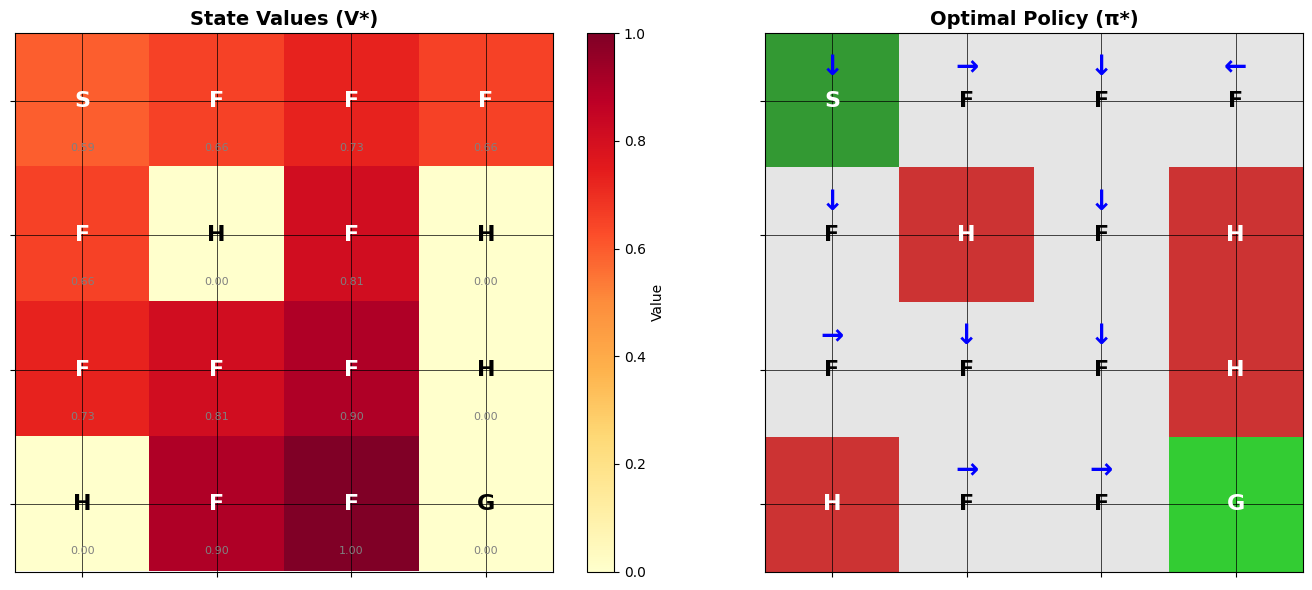

✓ Проверка пройдена!

----------------------------------------
Тест 2: Frozen Lake 4x4 со скольжением 25% (slip_chance=0.25)
----------------------------------------
Запуск Value Iteration...
iter    0 | diff: 0.75000 | V(start): 0.000
iter   21 | diff: 0.00001 | V(start): 0.309

Результаты тестирования (1000 эпизодов):
Среднее вознаграждение: 0.7390
Процент успешных эпизодов: 73.9%

Визуализация оптимальной политики (со скольжением):


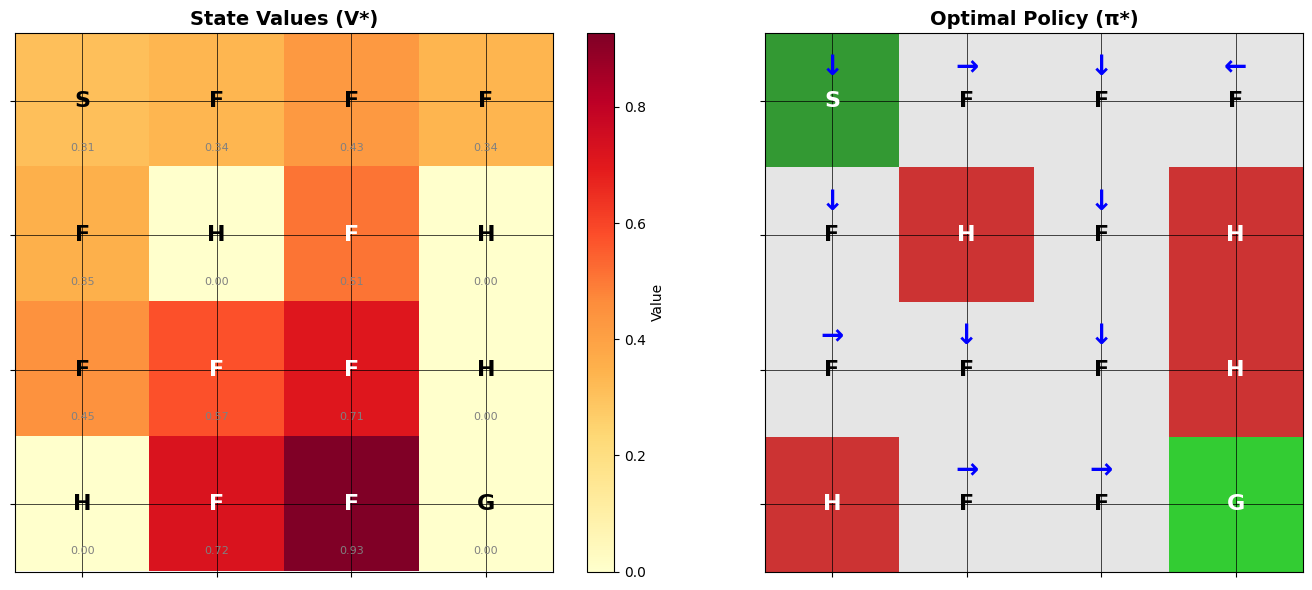

✓ Проверка пройдена!

----------------------------------------
Тест 3: Frozen Lake 8x8 со скольжением 20% (slip_chance=0.2)
----------------------------------------
Запуск Value Iteration...
iter    0 | diff: 0.80000 | V(start): 0.000
iter   35 | diff: 0.00001 | V(start): 0.136

Результаты тестирования (1000 эпизодов):
Среднее вознаграждение: 0.8820
Процент успешных эпизодов: 88.2%

Визуализация оптимальной политики (8x8):


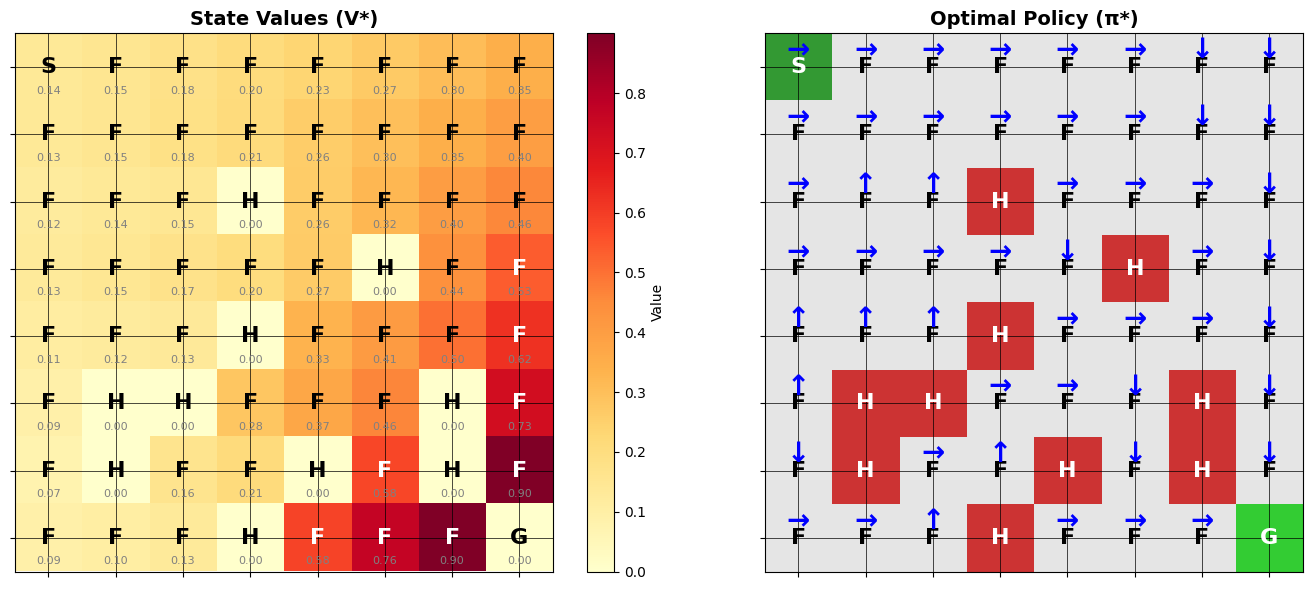

In [13]:
# Тестирование Frozen Lake
print("\n" + "="*60)
print("Frozen Lake Environment")
print("="*60)

# Тест 1: без скольжения
print("\n" + "-"*40)
print("Тест 1: Frozen Lake 4x4 без скольжения (slip_chance=0)")
print("-"*40)

mdp_frozen = FrozenLakeEnv(slip_chance=0)
print("Начальное состояние:")
mdp_frozen.render()

print("Запуск Value Iteration...")
state_values = value_iteration(mdp_frozen, num_iter=200)

avg_reward, success_rate = test_agent(mdp_frozen, state_values)
print(f"\nРезультаты тестирования (1000 эпизодов):")
print(f"Среднее вознаграждение: {avg_reward:.4f}")
print(f"Процент успешных эпизодов: {success_rate*100:.1f}%")

print("\nВизуализация оптимальной политики:")
draw_policy(mdp_frozen, state_values)

assert success_rate > 0.8, f"Слишком низкий процент успеха: {success_rate*100:.1f}%"
print("✓ Проверка пройдена!")

# Тест 2: со скольжением 0.25
print("\n" + "-"*40)
print("Тест 2: Frozen Lake 4x4 со скольжением 25% (slip_chance=0.25)")
print("-"*40)

mdp_frozen_slip = FrozenLakeEnv(slip_chance=0.25)
print("Запуск Value Iteration...")
state_values_slip = value_iteration(mdp_frozen_slip, num_iter=300)

avg_reward_slip, success_rate_slip = test_agent(mdp_frozen_slip, state_values_slip)
print(f"\nРезультаты тестирования (1000 эпизодов):")
print(f"Среднее вознаграждение: {avg_reward_slip:.4f}")
print(f"Процент успешных эпизодов: {success_rate_slip*100:.1f}%")

print("\nВизуализация оптимальной политики (со скольжением):")
draw_policy(mdp_frozen_slip, state_values_slip)

assert success_rate_slip > 0.5, f"Слишком низкий процент успеха: {success_rate_slip*100:.1f}%"
print("✓ Проверка пройдена!")

# Тест 3: карта 8x8 со скольжением 0.2
print("\n" + "-"*40)
print("Тест 3: Frozen Lake 8x8 со скольжением 20% (slip_chance=0.2)")
print("-"*40)

mdp_frozen_8x8 = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')
print("Запуск Value Iteration...")
state_values_8x8 = value_iteration(mdp_frozen_8x8, num_iter=500)

avg_reward_8x8, success_rate_8x8 = test_agent(mdp_frozen_8x8, state_values_8x8)
print(f"\nРезультаты тестирования (1000 эпизодов):")
print(f"Среднее вознаграждение: {avg_reward_8x8:.4f}")
print(f"Процент успешных эпизодов: {success_rate_8x8*100:.1f}%")

print("\nВизуализация оптимальной политики (8x8):")
draw_policy(mdp_frozen_8x8, state_values_8x8)
